In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
trip_df = pd.read_csv(r"../data/Trip_Details.csv")
location_df = pd.read_csv(r"../data/Location_Table.csv")

In [3]:
location_df.head()

,LocationID,Location,City
0,1,Newark Airport,"Newark, New Jersey"
1,2,Jamaica Bay,Queens
2,3,Allerton/Pelham Gardens,The Bronx
3,4,Alphabet City,Manhattan
4,5,Arden Heights,Staten Island


In [4]:
trip_df.head()

,Trip ID,Pickup Time,Drop Off Time,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,Surge Fee,Vehicle,Payment_type
0,1,6/1/24 0:42,6/1/24 1:04,1,5.60,79,226,19.5,2.0,UberX,Uber Pay
1,2,6/1/24 0:06,6/1/24 0:13,1,1.72,142,186,8.0,0.0,Uber Black,Cash
2,3,6/1/24 0:08,6/1/24 0:21,1,3.41,229,238,13.0,0.0,Uber Black,Cash
3,4,6/1/24 0:28,6/1/24 0:37,1,1.81,188,35,9.0,0.0,UberX,Cash
4,5,6/1/24 0:38,6/1/24 0:45,1,1.89,100,137,8.0,0.0,Uber Black,Cash


In [20]:
trip_df.columns

Index(['Trip ID', 'Pickup Time', 'Drop Off Time', 'passenger_count',
       'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount',
       'Surge Fee', 'Vehicle', 'Payment_type'],
      dtype='object')

In [21]:
location_df.columns

Index(['LocationID', 'Location', 'City'], dtype='object')

In [5]:
trip_df.describe()

,Trip ID,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,Surge Fee
count,103728.000000,103728.000000,103728.000000,103728.000000,103728.000000,103728.000000,103728.000000
mean,57422.229196,1.412136,3.363931,159.241410,153.537907,12.998337,1.979999
std,33812.530174,1.031418,3.192828,68.133216,73.585841,9.078582,2.421460
min,1.000000,1.000000,1.010000,1.000000,1.000000,2.500000,0.000000
25%,27899.750000,1.000000,1.530000,107.000000,87.000000,7.500000,0.000000
50%,56618.500000,1.000000,2.280000,151.000000,151.000000,10.000000,1.960000
75%,86859.250000,1.000000,3.800000,234.000000,233.000000,14.500000,3.000000
max,116924.000000,6.000000,144.100000,265.000000,265.000000,563.790000,117.930000


In [6]:
location_df.describe()

,LocationID
count,265.000000
mean,133.000000
std,76.643112
min,1.000000
25%,67.000000
50%,133.000000
75%,199.000000
max,265.000000


In [7]:
trip_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103728 entries, 0 to 103727
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Trip ID          103728 non-null  int64  
 1   Pickup Time      103728 non-null  object 
 2   Drop Off Time    103728 non-null  object 
 3   passenger_count  103728 non-null  int64  
 4   trip_distance    103728 non-null  float64
 5   PULocationID     103728 non-null  int64  
 6   DOLocationID     103728 non-null  int64  
 7   fare_amount      103728 non-null  float64
 8   Surge Fee        103728 non-null  float64
 9   Vehicle          103728 non-null  object 
 10  Payment_type     103728 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.7+ MB


In [8]:
location_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   LocationID  265 non-null    int64 
 1   Location    264 non-null    object
 2   City        263 non-null    object
dtypes: int64(1), object(2)
memory usage: 6.3+ KB


In [9]:
trip_df.shape

(103728, 11)

In [10]:
location_df.shape

(265, 3)

In [12]:
print(f"trip_df missing_values :\n {trip_df.isnull().sum()}")

trip_df missing_values :
 Trip ID            0
Pickup Time        0
Drop Off Time      0
passenger_count    0
trip_distance      0
PULocationID       0
DOLocationID       0
fare_amount        0
Surge Fee          0
Vehicle            0
Payment_type       0
dtype: int64


In [14]:
print(f"location_df missing values : \n {location_df.isnull().sum()}")

location_df missing values : 
 LocationID    0
Location      1
City          2
dtype: int64


In [15]:
print("\n--- Duplicates ---")
print(f"Trip DF duplicates: {trip_df.duplicated().sum()}")
print(f"Location DF duplicates: {location_df.duplicated().sum()}")



--- Duplicates ---
Trip DF duplicates: 0
Location DF duplicates: 0


In [16]:
print(trip_df['Vehicle'].value_counts())

Vehicle
UberX           38744
Uber Comfort    17078
Uber Black      16710
UberXL          16698
Uber Green      14498
Name: count, dtype: int64


In [17]:
print(trip_df["Payment_type"].value_counts())

Payment_type
Uber Pay      69530
Cash          33434
Amazon Pay      584
Google Pay      180
Name: count, dtype: int64


In [18]:
print("--- Data Statistics ---")
print(trip_df[['passenger_count', 'trip_distance', 'fare_amount', 'Surge Fee']].describe())

--- Data Statistics ---
       passenger_count  trip_distance    fare_amount      Surge Fee
count    103728.000000  103728.000000  103728.000000  103728.000000
mean          1.412136       3.363931      12.998337       1.979999
std           1.031418       3.192828       9.078582       2.421460
min           1.000000       1.010000       2.500000       0.000000
25%           1.000000       1.530000       7.500000       0.000000
50%           1.000000       2.280000      10.000000       1.960000
75%           1.000000       3.800000      14.500000       3.000000
max           6.000000     144.100000     563.790000     117.930000


In [19]:
df = trip_df.copy()

In [20]:
location_df['Location'].fillna('Unknown',inplace=True)
location_df['City'].fillna('Unknown',inplace=True)

In [21]:
print(location_df.isnull().sum())

LocationID    0
Location      0
City          0
dtype: int64


In [22]:
Q1_dist = df['trip_distance'].quantile(0.25)
Q3_dist = df['trip_distance'].quantile(0.75)
IQR_dist = Q3_dist - Q1_dist
lower_bound_dist = Q1_dist - 1.5 * IQR_dist
upper_bound_dist = Q3_dist + 1.5 * IQR_dist
print(f"\nTrip Distance - Removing outliers outside [{lower_bound_dist:.2f}, {upper_bound_dist:.2f}]")
df = df[(df['trip_distance'] >= lower_bound_dist) & (df['trip_distance'] <= upper_bound_dist)]


Trip Distance - Removing outliers outside [-1.87, 7.20]


In [24]:
Q1_fare = df['fare_amount'].quantile(0.25)
Q3_fare = df['fare_amount'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_dist + 1.5 * IQR_fare

print(f"Fare Amount - Removing outliers outside [{lower_bound_fare:.2f}, {upper_bound_fare:.2f}]")
df = df[(df['fare_amount'] >= lower_bound_fare) & (df['fare_amount'] <= upper_bound_fare)]


Fare Amount - Removing outliers outside [-0.75, 12.05]


In [25]:
df['Pickup Time'] = pd.to_datetime(df['Pickup Time'],format="%m/%d/%y %H:%M")
df['Drop Off Time'] = pd.to_datetime(df['Drop Off Time'],format="%m/%d/%y %H:%M")

In [26]:
df = df.merge(location_df , left_on='PULocationID',right_on='LocationID',how='left')
df.rename(columns={"Location_dropoff" : "Dropoff_Location", "City_dropoff": "Dropoff_City"},inplace=True)
df.drop(columns=['LocationID'],inplace = True)


In [27]:
df = df.merge(location_df , left_on='DOLocationID',right_on='LocationID',how='left',suffixes=('', '_dropoff'))
df.rename(columns={"Location_dropoff" : "Dropoff_Location", "City_dropoff": "Dropoff_City"},inplace=True)
df.drop(columns=['LocationID'],inplace=True)

In [29]:
# Time - Based Features 
df['Trip_Duration_Minutes'] = (df['Drop Off Time'] - df['Pickup Time']).dt.total_seconds() / 60
df['Pickup_Hour'] = df['Pickup Time'].dt.hour
df['Pickup_Day'] = df['Pickup Time'].dt.day
df['Pickup_Month'] = df['Pickup Time'].dt.month
df['Pickup_DayOfWeek'] = df['Pickup Time'].dt.dayofweek
df['Pickup_Quarter'] = df["Pickup Time"].dt.quarter
df['Pickup_Date'] = df["Pickup Time"].dt.date 

In [30]:
# Categorical time Features 
df['Is_Weekend'] = df['Pickup_DayOfWeek'].apply(lambda x : 1 if x >=5 else 0)
df['Is_Peak_Hour'] = df['Pickup_Hour'].apply(lambda x : 1 if x in [7,8,9,17,18,19] else 0)
df['Time_Period'] = pd.cut(df['Pickup_Hour'],bins=[0,6,12,18,24],
                           labels=['Night' , 'Morning' , 'Afternoon','Evening'],
                           right=False)


In [31]:
# Price - Based Features 
df['Cost_Per_Distance'] = df['fare_amount'] / (df['trip_distance'] + 0.1)
df['Cost_Per_Minute'] = df['fare_amount'] / (df['Trip_Duration_Minutes'] + 0.1)
df["Total_Amount"] = df['fare_amount'] + df['Surge Fee']
df['Surge_Percentage'] = (df['Surge Fee'] / df['fare_amount'] * 100).round(2)


In [32]:
# Trip Features
df['Distance_Category'] = pd.cut(df['trip_distance'],
                                 bins=[0,1.5,3,5,150],
                                 labels=['Short','Medium','Long','Very Long'])
df['Fare_Category'] = pd.cut(df['fare_amount'],
                             bins=[0,7.5,10,15,600],
                             labels = ['Cheap','Standard','Premium','Luxury'])


In [34]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split


In [35]:
le_vehicle = LabelEncoder()
le_payment = LabelEncoder()
le_time_period = LabelEncoder()


In [36]:
df["Vehicel_Encoded"] = le_vehicle.fit_transform(df['Vehicle'])
df['Payment_Type_Encoded'] = le_payment.fit_transform(df['Payment_type'])
df["Time_Period-Encoded"] = le_time_period.fit_transform(df['Time_Period'].astype(str))

In [37]:
# 6. One-hot encoding for categorical features
df = pd.get_dummies(df, columns=['Vehicle', 'Payment_type'], drop_first=True)


In [38]:
# 7. Remove invalid trip durations
df = df[df['Trip_Duration_Minutes'] > 0]

In [39]:
print("\nNew Features Created:")
print(f"Total features: {df.shape[1]}")
print("\nSample of engineered features:")
print(df[['Trip_Duration_Minutes', 'Pickup_Hour', 'Is_Weekend', 'Is_Peak_Hour', 
          'Cost_Per_Distance', 'Cost_Per_Minute', 'Total_Amount', 'Surge_Percentage']].head(10))


New Features Created:
Total features: 39

Sample of engineered features:
   Trip_Duration_Minutes  Pickup_Hour  Is_Weekend  Is_Peak_Hour  \
0                    7.0            0           1             0   
1                    9.0            0           1             0   
2                    7.0            0           1             0   
3                    8.0            0           1             0   
4                    3.0            0           1             0   
5                    9.0            0           1             0   
6                    4.0            0           1             0   
7                    7.0            0           1             0   
8                   12.0            0           1             0   
9                   11.0            0           1             0   

   Cost_Per_Distance  Cost_Per_Minute  Total_Amount  Surge_Percentage  
0           4.395604         1.126761          8.00              0.00  
1           4.712042         0.989011       

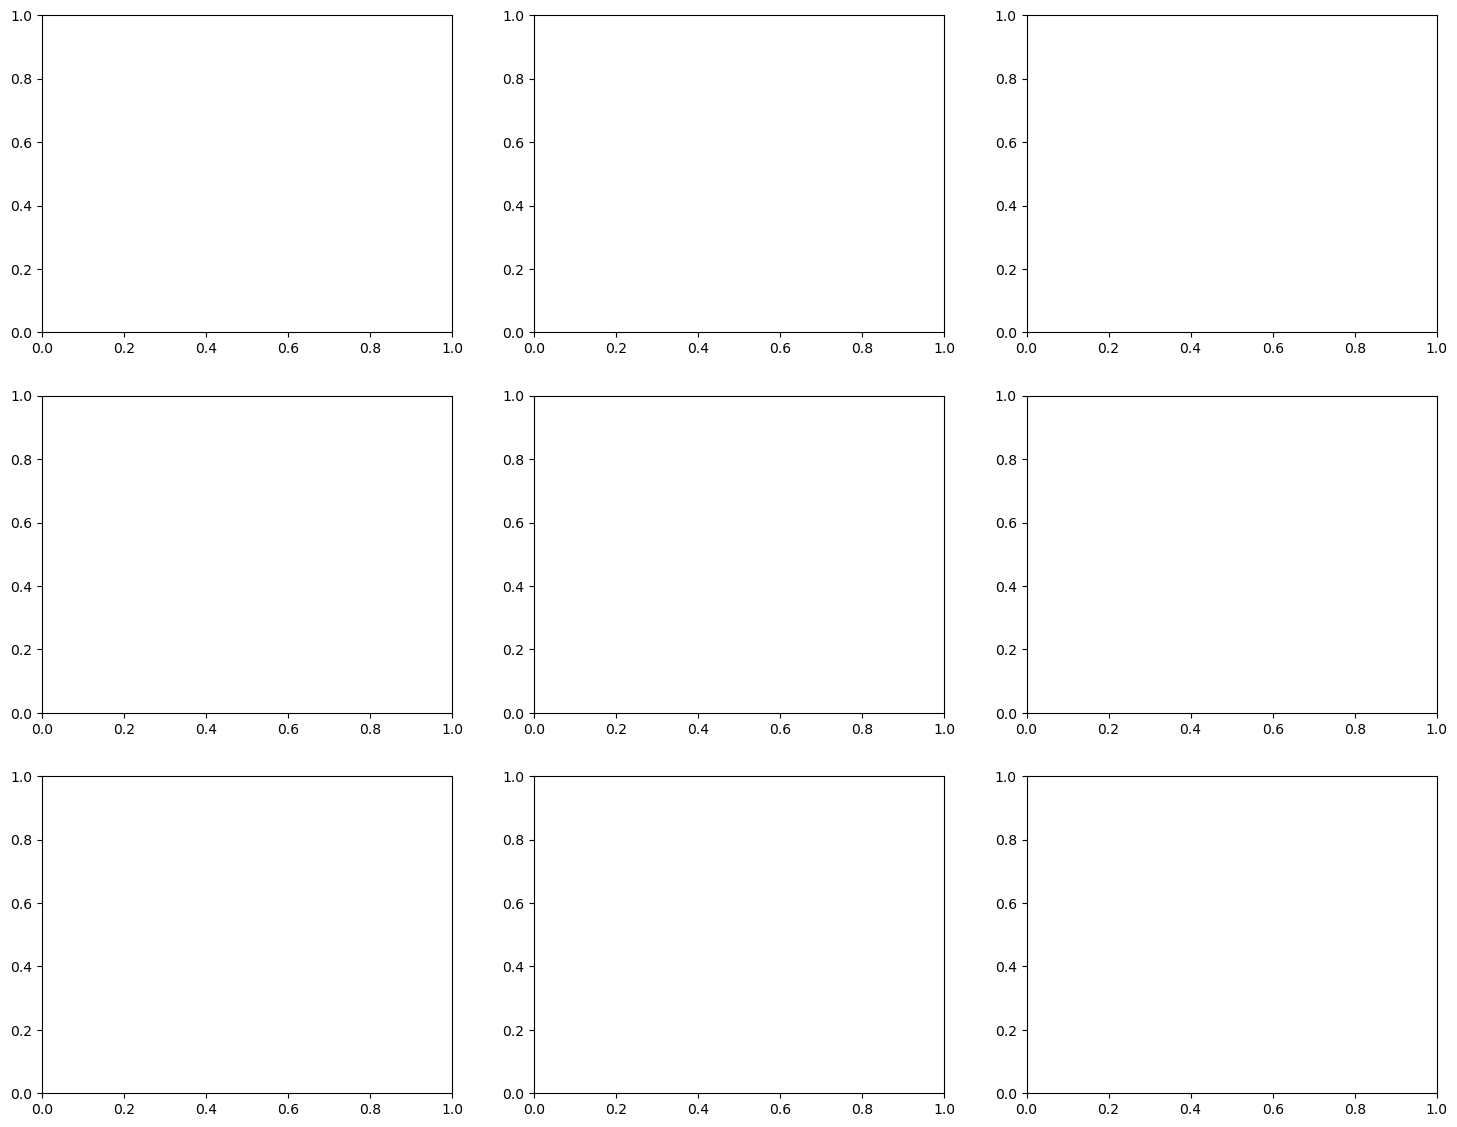

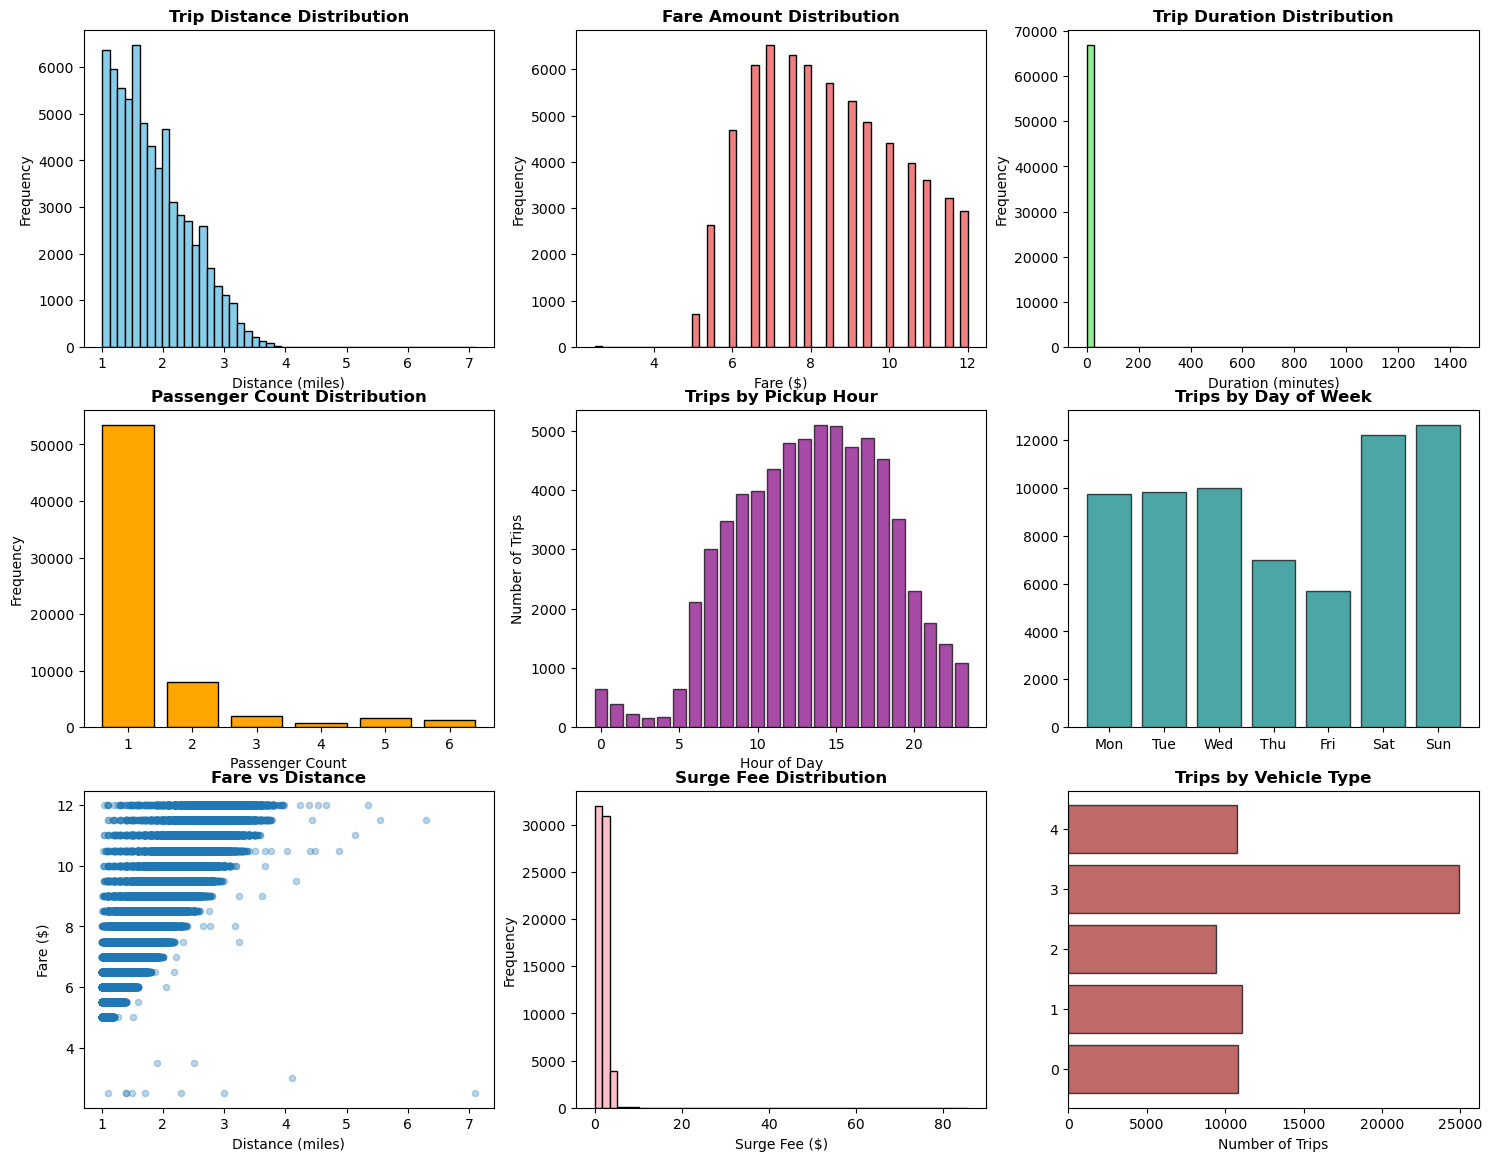

In [48]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
# 1. Trip distance distribution
axes[0, 0].hist(df['trip_distance'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Trip Distance Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Distance (miles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 1].hist(df['fare_amount'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Fare Amount Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Fare ($)')
axes[0, 1].set_ylabel('Frequency')
# 3. Trip duration distribution
axes[0, 2].hist(df['Trip_Duration_Minutes'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Trip Duration Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Duration (minutes)')
axes[0, 2].set_ylabel('Frequency')
# 4. Passenger count
passenger_counts = df['passenger_count'].value_counts().sort_index()
axes[1, 0].bar(passenger_counts.index, passenger_counts.values, color='orange', edgecolor='black')
axes[1, 0].set_title('Passenger Count Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Passenger Count')
axes[1, 0].set_ylabel('Frequency')
# 5. Trips by hour
hourly_trips = df['Pickup_Hour'].value_counts().sort_index()
axes[1, 1].bar(hourly_trips.index, hourly_trips.values, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Trips by Pickup Hour', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Number of Trips')
# 6. Trips by day of week
daily_trips = df['Pickup_DayOfWeek'].value_counts().sort_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1, 2].bar(daily_trips.index, daily_trips.values, color='teal', alpha=0.7, edgecolor='black')
axes[1, 2].set_title('Trips by Day of Week', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(range(7))
axes[1, 2].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
# 7. Fare vs Distance
axes[2, 0].scatter(df['trip_distance'], df['fare_amount'], alpha=0.3, s=20)
axes[2, 0].set_title('Fare vs Distance', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Distance (miles)')
axes[2, 0].set_ylabel('Fare ($)')
# 8. Surge Fee distribution
axes[2, 1].hist(df['Surge Fee'], bins=50, color='pink', edgecolor='black')
axes[2, 1].set_title('Surge Fee Distribution', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Surge Fee ($)')
axes[2, 1].set_ylabel('Frequency')
# 9. Vehicle type
vehicle_counts = df["Vehicel_Encoded"].value_counts()
axes[2, 2].barh(vehicle_counts.index, vehicle_counts.values, color='brown', alpha=0.7, edgecolor='black')
axes[2, 2].set_title('Trips by Vehicle Type', fontsize=12, fontweight='bold')
axes[2, 2].set_xlabel('Number of Trips')
plt.show()

In [ ]:
trip_df.shape

(103728, 11)

In [ ]:
trip_df.shape

(103728, 11)

In [50]:
plt.savefig(r'../eda_visualizations.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations saved as 'eda_visualizations.png'")

✓ Visualizations saved as 'eda_visualizations.png'


<Figure size 640x480 with 0 Axes>

In [51]:
df.to_csv(r'../data/processed_trip_data.csv', index=False)
print("Processed data saved as 'processed_trip_data.csv'")

print(f"\nFinal processed dataset shape: {df.shape}")
print("\nColumns in final dataset:")
print(df.columns.tolist())

Processed data saved as 'processed_trip_data.csv'

Final processed dataset shape: (67080, 39)

Columns in final dataset:
['Trip ID', 'Pickup Time', 'Drop Off Time', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'Surge Fee', 'Location', 'City', 'Dropoff_Location', 'Dropoff_City', 'Trip_Duration_Minutes', 'Pickup_Hour', 'Pickup_Day', 'Pickup_Month', 'Pickup_DayOfWeek', 'Pickup_Quarter', 'Pickup_Date', 'Is_Weekend', 'Is_Peak_Hour', 'Time_Period', 'Cost_Per_Distance', 'Cost_Per_Minute', 'Total_Amount', 'Surge_Percentage', 'Distance_Category', 'Fare_Category', 'Vehicel_Encoded', 'Payment_Type_Encoded', 'Time_Period-Encoded', 'Vehicle_Uber Comfort', 'Vehicle_Uber Green', 'Vehicle_UberX', 'Vehicle_UberXL', 'Payment_type_Cash', 'Payment_type_Google Pay', 'Payment_type_Uber Pay']


In [53]:
df = pd.read_csv(r"../data\processed_trip_data.csv")

In [54]:
df.head()

,Trip ID,Pickup Time,Drop Off Time,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,Surge Fee,Location,...,Vehicel_Encoded,Payment_Type_Encoded,Time_Period-Encoded,Vehicle_Uber Comfort,Vehicle_Uber Green,Vehicle_UberX,Vehicle_UberXL,Payment_type_Cash,Payment_type_Google Pay,Payment_type_Uber Pay
0,2,2024-06-01 00:06:00,2024-06-01 00:13:00,1,1.72,142,186,8.0,0.0,Lincoln Square East,...,0,1,3,False,False,False,False,True,False,False
1,4,2024-06-01 00:28:00,2024-06-01 00:37:00,1,1.81,188,35,9.0,0.0,Prospect-Lefferts Gardens,...,3,1,3,False,False,True,False,True,False,False
2,5,2024-06-01 00:38:00,2024-06-01 00:45:00,1,1.89,100,137,8.0,0.0,Garment District,...,0,1,3,False,False,False,False,True,False,False
3,7,2024-06-01 00:40:00,2024-06-01 00:48:00,2,2.05,142,141,8.5,0.0,Lincoln Square East,...,3,1,3,False,False,True,False,True,False,False
4,9,2024-06-01 00:20:00,2024-06-01 00:23:00,1,1.10,48,246,5.5,0.0,Clinton East,...,2,1,3,False,True,False,False,True,False,False


In [55]:
df.columns

Index(['Trip ID', 'Pickup Time', 'Drop Off Time', 'passenger_count',
       'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount',
       'Surge Fee', 'Location', 'City', 'Dropoff_Location', 'Dropoff_City',
       'Trip_Duration_Minutes', 'Pickup_Hour', 'Pickup_Day', 'Pickup_Month',
       'Pickup_DayOfWeek', 'Pickup_Quarter', 'Pickup_Date', 'Is_Weekend',
       'Is_Peak_Hour', 'Time_Period', 'Cost_Per_Distance', 'Cost_Per_Minute',
       'Total_Amount', 'Surge_Percentage', 'Distance_Category',
       'Fare_Category', 'Vehicel_Encoded', 'Payment_Type_Encoded',
       'Time_Period-Encoded', 'Vehicle_Uber Comfort', 'Vehicle_Uber Green',
       'Vehicle_UberX', 'Vehicle_UberXL', 'Payment_type_Cash',
       'Payment_type_Google Pay', 'Payment_type_Uber Pay'],
      dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67080 entries, 0 to 67079
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Trip ID                  67080 non-null  int64  
 1   Pickup Time              67080 non-null  object 
 2   Drop Off Time            67080 non-null  object 
 3   passenger_count          67080 non-null  int64  
 4   trip_distance            67080 non-null  float64
 5   PULocationID             67080 non-null  int64  
 6   DOLocationID             67080 non-null  int64  
 7   fare_amount              67080 non-null  float64
 8   Surge Fee                67080 non-null  float64
 9   Location                 67080 non-null  object 
 10  City                     67080 non-null  object 
 11  Dropoff_Location         67080 non-null  object 
 12  Dropoff_City             67080 non-null  object 
 13  Trip_Duration_Minutes    67080 non-null  float64
 14  Pickup_Hour           

In [59]:
# Check what columns actually exist
print("Columns in df_model:")
print(df.columns.tolist())
print(f"\nTotal columns: {len(df.columns)}")

# Filter columns_to_drop to only include columns that exist
columns_to_drop = [
    'Trip ID','Pickup Time','Drop Off Time','Pickup_Date',
    'Dropoff_Location','Distance_Category','Fare_Category',
    'Time_Period'
]

# Only drop columns that actually exist
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
print(f"\nColumns to drop: {columns_to_drop}")

df_model = df.drop(columns=columns_to_drop)

Columns in df_model:
['Trip ID', 'Pickup Time', 'Drop Off Time', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'Surge Fee', 'Location', 'City', 'Dropoff_Location', 'Dropoff_City', 'Trip_Duration_Minutes', 'Pickup_Hour', 'Pickup_Day', 'Pickup_Month', 'Pickup_DayOfWeek', 'Pickup_Quarter', 'Pickup_Date', 'Is_Weekend', 'Is_Peak_Hour', 'Time_Period', 'Cost_Per_Distance', 'Cost_Per_Minute', 'Total_Amount', 'Surge_Percentage', 'Distance_Category', 'Fare_Category', 'Vehicel_Encoded', 'Payment_Type_Encoded', 'Time_Period-Encoded', 'Vehicle_Uber Comfort', 'Vehicle_Uber Green', 'Vehicle_UberX', 'Vehicle_UberXL', 'Payment_type_Cash', 'Payment_type_Google Pay', 'Payment_type_Uber Pay']

Total columns: 39

Columns to drop: ['Trip ID', 'Pickup Time', 'Drop Off Time', 'Pickup_Date', 'Dropoff_Location', 'Distance_Category', 'Fare_Category', 'Time_Period']


In [60]:
# Check the final dataframe shape and columns
print(f"Final df_model shape: {df_model.shape}")
print(f"\nColumns in df_model:")
print(df_model.columns.tolist())
print(f"\nData types:")
print(df_model.dtypes)

Final df_model shape: (67080, 31)

Columns in df_model:
['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'Surge Fee', 'Location', 'City', 'Dropoff_City', 'Trip_Duration_Minutes', 'Pickup_Hour', 'Pickup_Day', 'Pickup_Month', 'Pickup_DayOfWeek', 'Pickup_Quarter', 'Is_Weekend', 'Is_Peak_Hour', 'Cost_Per_Distance', 'Cost_Per_Minute', 'Total_Amount', 'Surge_Percentage', 'Vehicel_Encoded', 'Payment_Type_Encoded', 'Time_Period-Encoded', 'Vehicle_Uber Comfort', 'Vehicle_Uber Green', 'Vehicle_UberX', 'Vehicle_UberXL', 'Payment_type_Cash', 'Payment_type_Google Pay', 'Payment_type_Uber Pay']

Data types:
passenger_count              int64
trip_distance              float64
PULocationID                 int64
DOLocationID                 int64
fare_amount                float64
Surge Fee                  float64
Location                    object
City                        object
Dropoff_City                object
Trip_Duration_Minutes      float64
Pickup_Hour   

In [61]:
# Define target variable - predicting fare_amount
target = 'fare_amount'
X = df_model.drop(columns=[target, 'Surge Fee', 'Total_Amount', 'Trip_Duration_Minutes'])
y = df_model[target]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures list ({len(X.columns)} total):")
print(X.columns.tolist())

Features shape: (67080, 27)
Target shape: (67080,)

Features list (27 total):
['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'Location', 'City', 'Dropoff_City', 'Pickup_Hour', 'Pickup_Day', 'Pickup_Month', 'Pickup_DayOfWeek', 'Pickup_Quarter', 'Is_Weekend', 'Is_Peak_Hour', 'Cost_Per_Distance', 'Cost_Per_Minute', 'Surge_Percentage', 'Vehicel_Encoded', 'Payment_Type_Encoded', 'Time_Period-Encoded', 'Vehicle_Uber Comfort', 'Vehicle_Uber Green', 'Vehicle_UberX', 'Vehicle_UberXL', 'Payment_type_Cash', 'Payment_type_Google Pay', 'Payment_type_Uber Pay']


In [66]:
# Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data split and scaled successfully!")

Training set size: (53664, 27)
Test set size: (13416, 27)

✓ Data split and scaled successfully!


In [65]:
# just before train_test_split…
print("non‑numeric columns in X:",
      X.select_dtypes(include=['object','category']).columns.tolist())

non‑numeric columns in X: []


In [64]:
from sklearn.preprocessing import LabelEncoder
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [70]:
# Import ML Libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error , accuracy_score
import xgboost as xgb

print("All ML libraries imported successfully!")

All ML libraries imported successfully!


In [72]:
# ====== MODEL 1: LINEAR REGRESSION =====
print("="*60)
print("MODEL 1: LINEAR REGRESSION")
print("="*60)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"RMSE: ${lr_rmse:.2f}")
print(f"MAE: ${lr_mae:.2f}")
print(f"R² Score: {lr_r2:.4f}")
print(f"Accuracy Score : {accuracy_score(y_test , y_pred_lr)}")

MODEL 1: LINEAR REGRESSION
RMSE: $0.41
MAE: $0.26
R² Score: 0.9504


ValueError: continuous is not supported

In [75]:
# ====== MODEL 2: RIDGE REGRESSION =====
print("\n" + "="*60)
print("MODEL 2: RIDGE REGRESSION")
print("="*60)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f"RMSE: ${ridge_rmse:.2f}")
# print(f"Accuracy Score: {acc_score:.4f}")
print(f"MAE: ${ridge_mae:.2f}")
print(f"R² Score: {ridge_r2:.4f}")




MODEL 2: RIDGE REGRESSION
RMSE: $0.41
MAE: $0.26
R² Score: 0.9504


In [74]:
# ====== MODEL 3: LASSO REGRESSION =====
print("\n" + "="*60)
print("MODEL 3: LASSO REGRESSION")
print("="*60)

lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print(f"RMSE: ${lasso_rmse:.2f}")
print(f"MAE: ${lasso_mae:.2f}")
print(f"R² Score: {lasso_r2:.4f}")


MODEL 3: LASSO REGRESSION
RMSE: $0.47
MAE: $0.34
R² Score: 0.9338


In [76]:
# ====== MODEL 4: RANDOM FOREST =====
print("\n" + "="*60)
print("MODEL 4: RANDOM FOREST REGRESSOR")
print("="*60)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"RMSE: ${rf_rmse:.2f}")
print(f"MAE: ${rf_mae:.2f}")
print(f"R² Score: {rf_r2:.4f}")

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features (Random Forest):")
print(feature_importance_rf.head(10))


MODEL 4: RANDOM FOREST REGRESSOR
RMSE: $0.05
MAE: $0.00
R² Score: 0.9992

Top 10 Important Features (Random Forest):
                 Feature  Importance
1          trip_distance    0.734211
15       Cost_Per_Minute    0.148612
14     Cost_Per_Distance    0.116917
18  Payment_Type_Encoded    0.000124
7            Pickup_Hour    0.000018
8             Pickup_Day    0.000017
3           DOLocationID    0.000016
6           Dropoff_City    0.000010
4               Location    0.000010
2           PULocationID    0.000010


In [77]:
# ====== MODEL 5: GRADIENT BOOSTING =====
print("\n" + "="*60)
print("MODEL 5: GRADIENT BOOSTING REGRESSOR")
print("="*60)

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print(f"RMSE: ${gb_rmse:.2f}")
print(f"MAE: ${gb_mae:.2f}")
print(f"R² Score: {gb_r2:.4f}")

# Feature Importance
feature_importance_gb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features (Gradient Boosting):")
print(feature_importance_gb.head(10))


MODEL 5: GRADIENT BOOSTING REGRESSOR
RMSE: $0.06
MAE: $0.04
R² Score: 0.9991

Top 10 Important Features (Gradient Boosting):
                    Feature  Importance
1             trip_distance    0.750698
14        Cost_Per_Distance    0.132024
15          Cost_Per_Minute    0.117256
25  Payment_type_Google Pay    0.000005
3              DOLocationID    0.000004
7               Pickup_Hour    0.000003
10         Pickup_DayOfWeek    0.000003
4                  Location    0.000002
16         Surge_Percentage    0.000002
18     Payment_Type_Encoded    0.000002


In [78]:
# ====== MODEL 6: XGBOOST =====
print("\n" + "="*60)
print("MODEL 6: XGBOOST REGRESSOR")
print("="*60)

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print(f"RMSE: ${xgb_rmse:.2f}")
print(f"MAE: ${xgb_mae:.2f}")
print(f"R² Score: {xgb_r2:.4f}")

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features (XGBoost):")
print(feature_importance_xgb.head(10))


MODEL 6: XGBOOST REGRESSOR
RMSE: $0.11
MAE: $0.04
R² Score: 0.9965

Top 10 Important Features (XGBoost):
                 Feature  Importance
1          trip_distance    0.697828
15       Cost_Per_Minute    0.160562
14     Cost_Per_Distance    0.103229
3           DOLocationID    0.007071
18  Payment_Type_Encoded    0.006297
6           Dropoff_City    0.005119
2           PULocationID    0.005116
5                   City    0.004330
22         Vehicle_UberX    0.002444
8             Pickup_Day    0.001811


In [79]:
# ====== MODEL COMPARISON =====
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

models_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 
              'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse, gb_rmse, xgb_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae, rf_mae, gb_mae, xgb_mae],
    'R² Score': [lr_r2, ridge_r2, lasso_r2, rf_r2, gb_r2, xgb_r2]
})

print(models_summary.sort_values('R² Score', ascending=False))
print("\n✓ Best Model: ", models_summary.loc[models_summary['R² Score'].idxmax(), 'Model'])


MODEL COMPARISON SUMMARY
               Model      RMSE       MAE  R² Score
3      Random Forest  0.050475  0.003495  0.999244
4  Gradient Boosting  0.055605  0.035229  0.999082
5            XGBoost  0.108308  0.040933  0.996519
1   Ridge Regression  0.408910  0.264534  0.950377
0  Linear Regression  0.408933  0.264481  0.950371
2   Lasso Regression  0.472347  0.337382  0.933786

✓ Best Model:  Random Forest


✓ Model visualizations saved as 'eda_visualizations.png'


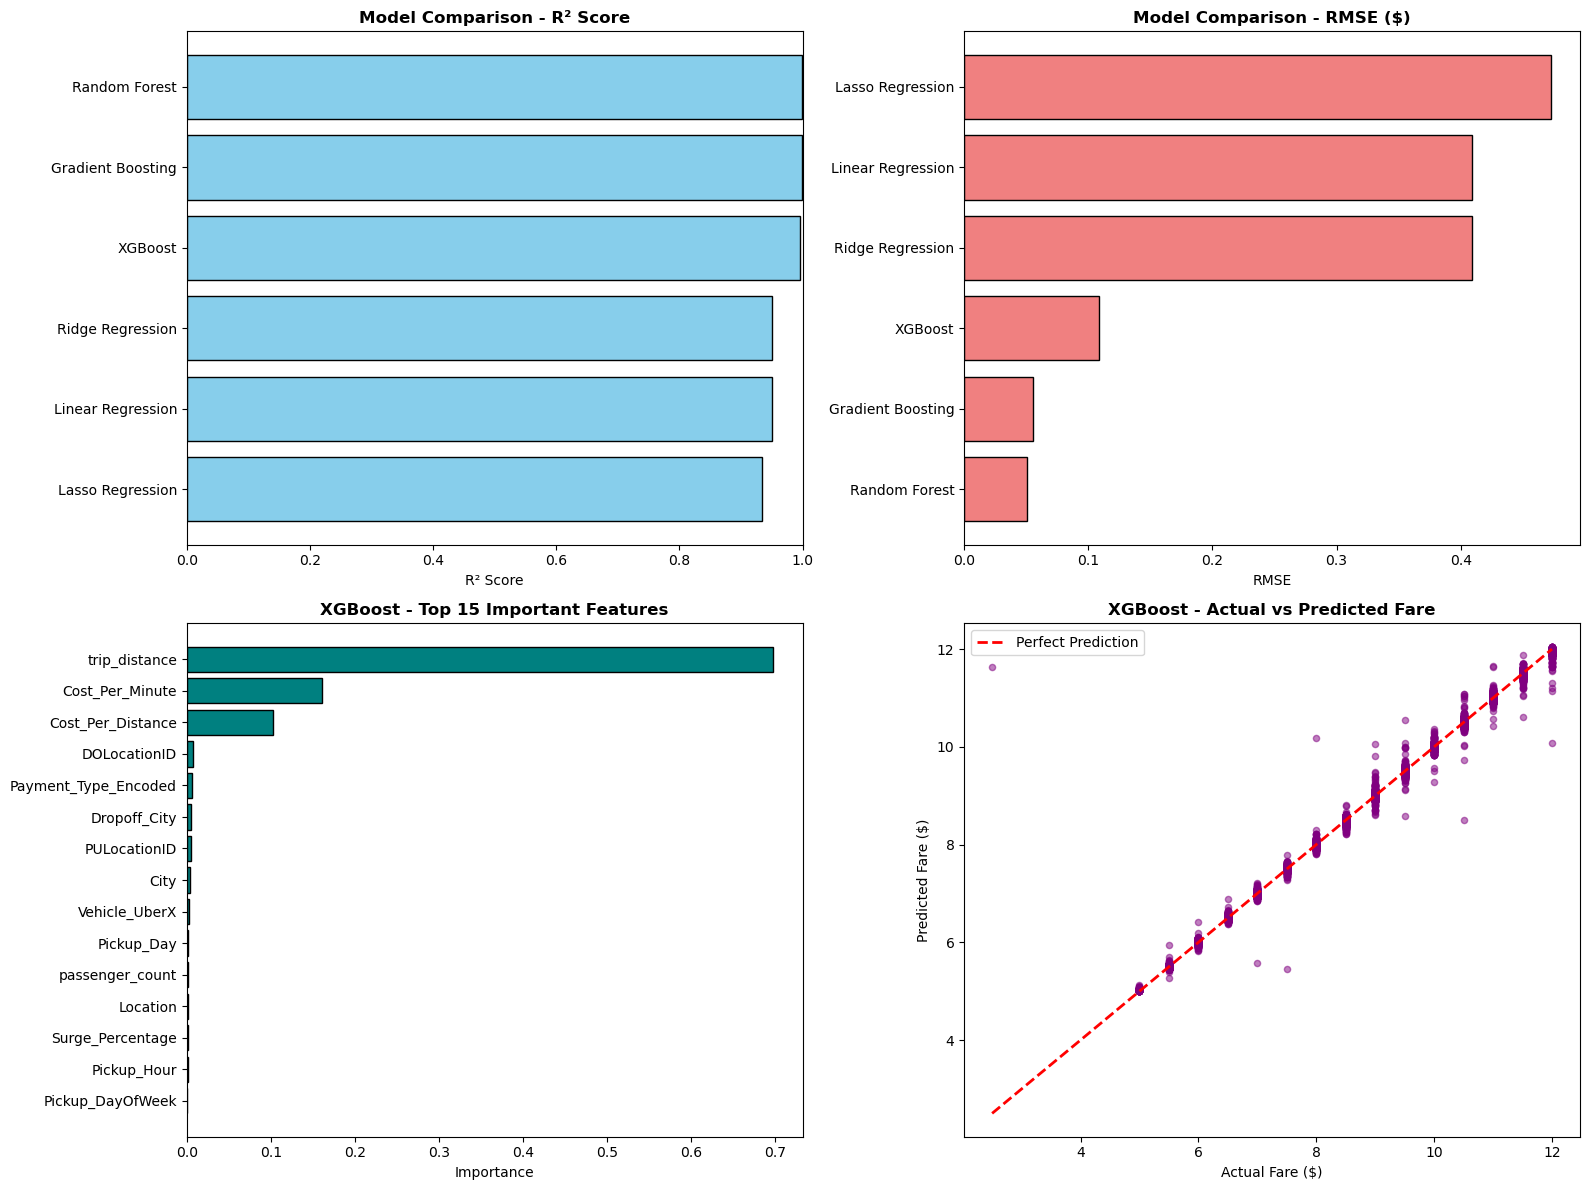

In [80]:
# ====== MODEL VISUALIZATIONS =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model Comparison - R² Score
ax1 = axes[0, 0]
models_sorted = models_summary.sort_values('R² Score', ascending=True)
ax1.barh(models_sorted['Model'], models_sorted['R² Score'], color='skyblue', edgecolor='black')
ax1.set_title('Model Comparison - R² Score', fontsize=12, fontweight='bold')
ax1.set_xlabel('R² Score')
ax1.set_xlim([0, 1])

# 2. Model Comparison - RMSE
ax2 = axes[0, 1]
models_sorted_rmse = models_summary.sort_values('RMSE', ascending=True)
ax2.barh(models_sorted_rmse['Model'], models_sorted_rmse['RMSE'], color='lightcoral', edgecolor='black')
ax2.set_title('Model Comparison - RMSE ($)', fontsize=12, fontweight='bold')
ax2.set_xlabel('RMSE')

# 3. Feature Importance - XGBoost (Top 15)
ax3 = axes[1, 0]
top_features_xgb = feature_importance_xgb.head(15)
ax3.barh(top_features_xgb['Feature'], top_features_xgb['Importance'], color='teal', edgecolor='black')
ax3.set_title('XGBoost - Top 15 Important Features', fontsize=12, fontweight='bold')
ax3.set_xlabel('Importance')
ax3.invert_yaxis()

# 4. Actual vs Predicted (XGBoost)
ax4 = axes[1, 1]
ax4.scatter(y_test, y_pred_xgb, alpha=0.5, s=20, color='purple')
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax4.set_title('XGBoost - Actual vs Predicted Fare', fontsize=12, fontweight='bold')
ax4.set_xlabel('Actual Fare ($)')
ax4.set_ylabel('Predicted Fare ($)')
ax4.legend()

plt.tight_layout()
plt.savefig(r'../eda_visualizations.png', dpi=300, bbox_inches='tight')
print("✓ Model visualizations saved as 'eda_visualizations.png'")
plt.show()

In [81]:
# ====== HYPERPARAMETER TUNING - XGBOOST =====
print("\n" + "="*60)
print("HYPERPARAMETER TUNING - XGBOOST")
print("="*60)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9]
}

xgb_grid = xgb.XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(xgb_grid, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_xgb = grid_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
best_xgb_mae = mean_absolute_error(y_test, y_pred_best_xgb)
best_xgb_r2 = r2_score(y_test, y_pred_best_xgb)

print(f"\nBest XGBoost Model Performance (After Tuning):")
print(f"RMSE: ${best_xgb_rmse:.2f}")
print(f"MAE: ${best_xgb_mae:.2f}")
print(f"R² Score: {best_xgb_r2:.4f}")

print("\n✓ Hyperparameter tuning completed!")


HYPERPARAMETER TUNING - XGBOOST
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters: {'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.8}
Best CV R² Score: 0.9978

Best XGBoost Model Performance (After Tuning):
RMSE: $0.10
MAE: $0.02
R² Score: 0.9968

✓ Hyperparameter tuning completed!


In [ ]:
                "# ====== SAVE BEST MODEL =====",
                "import joblib",
                "import os",
                "",
                "# Create models directory if it doesn't exist",
                "os.makedirs('../models', exist_ok=True)",
                "",
                "joblib.dump(best_xgb, r'../models/best_xgboost_model.pkl')",
                "joblib.dump(scaler, r'../models/scaler.pkl')",
                "",
                "print(\"✓ Best XGBoost model saved as 'best_xgboost_model.pkl'\")",
                "print(\"✓ Scaler saved as 'scaler.pkl'\")",
                "",
                "# ====== SAMPLE PREDICTIONS =====",
                "print(\"\\n\" + \"=\"*60)",
                "print(\"SAMPLE PREDICTIONS ON TEST SET\")",
                "print(\"=\"*60)",
                "",
                "sample_predictions = pd.DataFrame({",
                "    'Actual_Fare': y_test.head(20).values,",
                "    'Predicted_Fare': y_pred_best_xgb[:20],",
                "    'Error_Dollars': np.abs(y_test.head(20).values - y_pred_best_xgb[:20]),",
                "    'Error_Percent': (np.abs(y_test.head(20).values - y_pred_best_xgb[:20]) / y_test.head(20).values * 100).round(2)",
                "})",
                "",
                "print(sample_predictions)",
                "print(f\"\\nAverage Prediction Error: ${sample_predictions['Error_Dollars'].mean():.2f}\")",
                "print(f\"Average Prediction Error %: {sample_predictions['Error_Percent'].mean():.2f}%\")",
                "",
                "# ====== FULL PREDICTIONS CSV FOR POWER BI =====",
                "# Build a full predictions DataFrame from the test set features and the model predictions",
                "predictions_df = X_test.copy()",
                "# Ensure alignment: reset indices before adding actuals/predictions",
                "predictions_df = predictions_df.reset_index(drop=True)",
                "actuals = y_test.reset_index(drop=True)",
                "preds = pd.Series(y_pred_best_xgb, name='Predicted_Fare')",
                "predictions_df['Actual_Fare'] = actuals",
                "predictions_df['Predicted_Fare'] = preds",
                "predictions_df['Error_Dollars'] = (predictions_df['Actual_Fare'] - predictions_df['Predicted_Fare']).abs()",
                "predictions_df['Error_Percent'] = (predictions_df['Error_Dollars'] / predictions_df['Actual_Fare'] * 100).round(2)",
                "",
                "# Save CSV (Power BI can load this file)",
                "pred_csv_path = r'../data/predictions_full_test_set.csv'",
                "predictions_df.to_csv(pred_csv_path, index=False)",
                "print(f\"✓ Full predictions saved to {pred_csv_path}; shape: {predictions_df.shape}\")"

In [83]:
# Recreate model dataframe exactly like training
df_full_model = pd.get_dummies(df, drop_first=True)

# Ensure column alignment with training data
df_full_model = df_full_model.reindex(columns=X_train.columns, fill_value=0)

# Remove target column
X_full = df_full_model

In [84]:
full_predictions = best_xgb.predict(X_full)

In [85]:
full_data = df.copy()

full_data['Predicted_Fare'] = full_predictions
full_data['Actual_Fare'] = df['fare_amount']
full_data['Error_Dollars'] = (full_data['Actual_Fare'] - full_data['Predicted_Fare']).abs()
full_data['Error_Percent'] = (
    full_data['Error_Dollars'] / full_data['Actual_Fare'] * 100
).round(2)

full_data.to_csv("final_predictions_for_powerbi.csv", index=False)

print("✅ Export Ready for Power BI")
print(full_data.shape)

✅ Export Ready for Power BI
(67080, 43)
